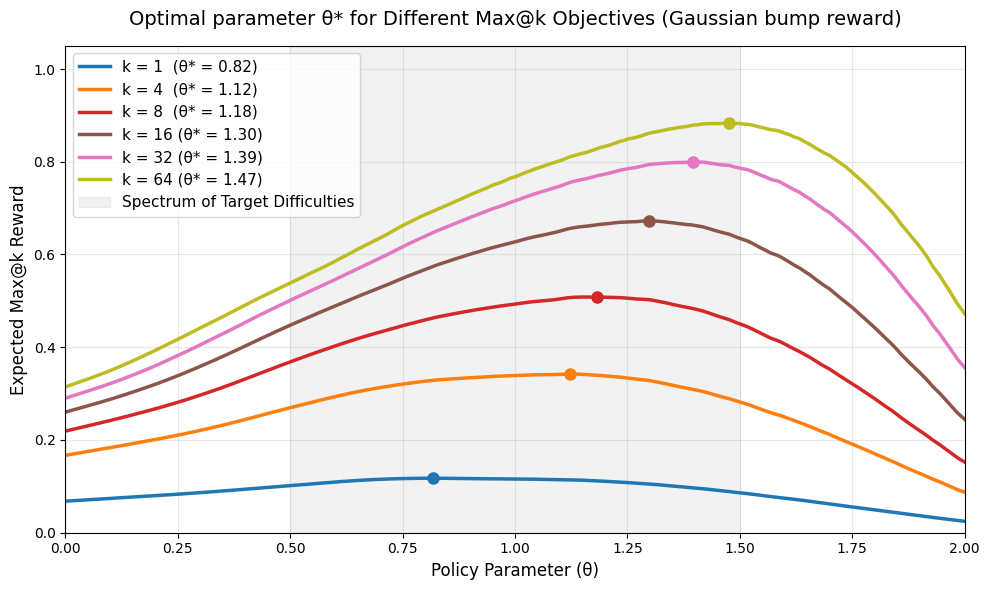

In [6]:
# =====================================================================
# 1. EMPIRICAL SAMPLING FOR THE CONTINUOUS SPECTRUM
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt

SIGMA = 0.2
THETA_INIT = 0.2
TAU_SCALE = 0.2
X_DIM = 16  # Must be >= 5 to support the complex non-linear mapping

def sample_data(n_problems, n_generations, sigma=SIGMA, theta_init=THETA_INIT):
    if X_DIM < 5:
        raise ValueError("X_DIM must be >= 5 for complex mapping")
    
    # 1. Generate features
    x0 = np.random.uniform(0.5, 1.5, n_problems)
    extras = np.random.standard_normal((n_problems, X_DIM - 1))
    X = np.column_stack([x0, extras])
    
    # 2. Complex, Non-Linear Feature Mapping to Target
    # Combines square, sine, cosine, and a cross-interaction term
    base_target = (
        x0**2 
        + 0.2 * np.sin(3 * extras[:, 0]) 
        + 0.2 * np.cos(3 * extras[:, 1]) 
        + 0.1 * extras[:, 2] * extras[:, 3]
    )

    W = 0.07 - 0.04 * x0
    Z = np.random.normal(loc=theta_init * x0[:, None], scale=sigma, size=(n_problems, n_generations))
    
    tau = (TAU_SCALE * np.sqrt(W))[:, np.newaxis]
    target = base_target[:, np.newaxis]

    # 3. Multi-Modal Reward Distribution
    # Mode 1: Safe but low reward (Very Broad) -> Shifted left by 0.6
    Y1 = 0.5 * np.exp(-((Z - target + 0.6) ** 2) / (2 * (2 * tau)**2))
    
    # Mode 2: Medium reward, medium risk -> Centered
    Y2 = 0.8 * np.exp(-((Z - target) ** 2) / (2 * tau**2))
    
    # Mode 3: High reward, high risk (Very Narrow) -> Shifted right by 0.5
    Y3 = 1.0 * np.exp(-((Z - target - 0.5) ** 2) / (2 * (tau / 2)**2))

    # Combine the modes. Clip to 1.0 to guarantee bounds.
    Y = np.clip(Y1 + Y2 + Y3, 0.0, 1.0)

    # Score function remains the same (policy gradient of the Normal distribution)
    score = ((Z - theta_init * x0[:, None]) * x0[:, None]) / sigma**2
    return X, Z, Y, score

# =====================================================================
# 2. ANALYTICAL CURVE COMPUTATION (Updated for Multi-modal & Covariates)
# =====================================================================

def compute_analytical_curves(
    thetas,
    k_values,
    sigma=SIGMA,
    tau_scale=TAU_SCALE,
    n_x=256,
    N_oversample=4096, 
    seed=42,
    **kwargs
):
    """
    Computes E[max@k] curves using a fast Empirical U-Statistic,
    updated to mirror the multi-modal and non-linear properties of the new dataset.
    """
    thetas = np.asarray(thetas, dtype=np.float64)
    n_thetas = len(thetas)
    
    # 1. Setup Environment (Replicating the exact distribution of X)
    rng = np.random.default_rng(seed)
    x0 = np.linspace(0.5, 1.5, n_x)
    extras = rng.standard_normal((n_x, X_DIM - 1))
    
    base_target = (
        x0**2 
        + 0.2 * np.sin(3 * extras[:, 0]) 
        + 0.2 * np.cos(3 * extras[:, 1]) 
        + 0.1 * extras[:, 2] * extras[:, 3]
    )
    
    W = 0.07 - 0.04 * x0
    tau = tau_scale * np.sqrt(W)
    target = base_target
    
    # 2. Precompute Combinatorial Weights for all k
    from scipy.special import gammaln
    weights = {}
    for k in k_values:
        w = np.zeros(N_oversample)
        if k == 1:
            w[:] = 1.0 / N_oversample
        else:
            i = np.arange(k - 1, N_oversample)
            log_num = gammaln(i + 1) - gammaln(k) - gammaln(i - k + 2)
            log_den = gammaln(N_oversample + 1) - gammaln(k + 1) - gammaln(N_oversample - k + 1)
            w[k - 1:] = np.exp(log_num - log_den)
        weights[k] = w

    # 3. Fix the random noise
    epsilon = rng.standard_normal((n_x, N_oversample))
    expected_rewards = {k: np.zeros(n_thetas) for k in k_values}
    
    chunk_size = 50
    for i in range(0, n_thetas, chunk_size):
        theta_chunk = thetas[i : i + chunk_size] 
        
        # Reshape for 3D broadcasting
        theta_3d = theta_chunk[:, None, None]
        x0_3d = x0[None, :, None]
        epsilon_3d = epsilon[None, :, :]
        target_3d = target[None, :, None]
        tau_3d = tau[None, :, None]
        
        # Calculate Z (Note: theta only multiplies x0)
        Z = (theta_3d * x0_3d) + (sigma * epsilon_3d)
        
        # Calculate Multi-Modal Reward
        Y1 = 0.5 * np.exp(-((Z - target_3d + 0.6)**2) / (2 * (2 * tau_3d)**2))
        Y2 = 0.8 * np.exp(-((Z - target_3d)**2) / (2 * tau_3d**2))
        Y3 = 1.0 * np.exp(-((Z - target_3d - 0.5)**2) / (2 * (tau_3d / 2)**2))
        Y = np.clip(Y1 + Y2 + Y3, 0.0, 1.0)
        
        Y_sorted = np.sort(Y, axis=-1)
        
        for k in k_values:
            E_max_k_X = Y_sorted @ weights[k]
            expected_rewards[k][i : i + chunk_size] = np.mean(E_max_k_X, axis=1)
            
    return expected_rewards

# =====================================================================
# 2. COMPUTE THE CURVES
thetas = np.linspace(0.0, 2.0, 500)
k_values = [1, 4, 8, 16, 32, 64]
k_to_best_theta = {}

# results = compute_empirical_curves(thetas, k_values, N=5000)
results = compute_analytical_curves(
    thetas,
    k_values,
    sigma=0.2,
    n_x=256,
    n_jobs=8,
)

# =====================================================================
# 3. PLOT THE RESULTS
# =====================================================================
plt.figure(figsize=(10, 6))
n_k = len(k_values)
_base_cmap = plt.cm.tab20 if n_k > 10 else plt.cm.tab10
colors = _base_cmap(np.linspace(0, 1, n_k, endpoint=False))

for idx, k in enumerate(k_values):
    rewards = results[k]
    
    # Find the peak
    best_idx = np.argmax(rewards)
    best_theta = thetas[best_idx]
    k_to_best_theta[k] = best_theta
    max_reward = rewards[best_idx]
    
    plt.plot(thetas, rewards, label=f'k = {k:<2} (θ* = {best_theta:.2f})', 
             color=colors[idx], linewidth=2.5)
    
    # Mark the peak
    plt.plot(best_theta, max_reward, marker='o', markersize=8, color=colors[idx])

plt.title("Optimal parameter θ* for Different Max@k Objectives (Gaussian bump reward)", 
          fontsize=14, pad=15)
plt.xlabel("Policy Parameter (θ)", fontsize=12)
plt.ylabel("Expected Max@k Reward", fontsize=12)

plt.axvspan(0.5, 1.5, color='gray', alpha=0.1, label='Spectrum of Target Difficulties')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.xlim(0.0, 2.0)
plt.tight_layout()

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import norm
from scipy.integrate import quad


# =====================================================================
# 2. NEURAL ARCHITECTURE & ESTIMATORS
# =====================================================================
class SoftmaxNet(nn.Module):
    def __init__(self, num_bins: int = 20, hidden: int = 64, in_features: int = 1):
        super().__init__()
        self.num_bins = num_bins
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_bins),
            nn.Softmax(dim=-1) # Directly outputs a normalized PDF
        )

    def forward(self, x: torch.Tensor):
        return self.mlp(x)


def cross_entropy_loss(predicted_pdf: torch.Tensor, target_counts: torch.Tensor):
    """
    predicted_pdf: (n_X, num_bins) from the Softmax network.
    target_counts: (n_X, num_bins) the grouped empirical counts (e.g., C_total).
    """
    eps = 1e-8
    N = target_counts.sum(dim=-1, keepdim=True)
    
    # Standard Cross-Entropy over multinomial counts
    loss = -torch.sum(target_counts * torch.log(predicted_pdf + eps), dim=-1)
    
    # Divide by N to match the scale of the flattened N=1 loss
    return (loss / N.squeeze(-1)).mean()


def cramer_distance_loss(ps: torch.Tensor, target_counts: torch.Tensor):
    """
    ps: (n_X, num_bins) from the Softmax network.
    target_counts: (n_X, num_bins) the grouped empirical counts (e.g., C_total).
    """
    predicted_cdf = torch.cumsum(ps, dim=-1)
    
    # Create the Empirical Target CDF from the grouped counts
    target_pdf = target_counts / target_counts.sum(dim=-1, keepdim=True)
    target_cdf = torch.cumsum(target_pdf, dim=-1).to(ps.dtype)
    
    mse_loss = F.mse_loss(predicted_cdf, target_cdf, reduction='none').sum(dim=-1)
    return mse_loss.mean()


def max_at_k(ps: torch.Tensor, k: int, num_bins: int = 20):
    """
    Computes E[M_k] directly from a predicted point-estimate PDF.
    ps: (..., num_bins) probabilities summing to 1.
    """
    if k <= 0:
        return torch.zeros((*ps.shape[:-1],), device=ps.device, dtype=ps.dtype)

    # 1. Compute predicted CDF directly
    predicted_cdf = torch.cumsum(ps, dim=-1)
    
    # 2. Shift to get the PDF of M_k
    zero_pad = torch.zeros((*ps.shape[:-1], 1), device=ps.device, dtype=ps.dtype)
    shifted_cdf = torch.cat([zero_pad, predicted_cdf[..., :-1]], dim=-1)
    
    # P(M_k == b) = (F_b)^k - (F_{b-1})^k
    prob_m_k = (predicted_cdf ** k) - (shifted_cdf ** k)
    bin_values = (torch.arange(num_bins, device=ps.device, dtype=ps.dtype) + 0.5) / num_bins
    
    return torch.sum(prob_m_k * bin_values, dim=-1)


def conditional_max_at_k(ps: torch.Tensor, Y: torch.Tensor, k: int, num_bins: int = 20):
    """
    Computes Q(y) = E[max(Y, M_{k-1})] directly from a point-estimate PDF.
    ps: (..., num_bins) probabilities summing to 1.
    Y: (...,) empirical rollout values.
    """
    k_minus_1 = k - 1
    
    if k_minus_1 <= 0:
        return Y

    # Expand ps (n_X, bins) to match Y's shape (n_X, n_Z, bins)
    while ps.dim() < Y.dim() + 1:
        ps = ps.unsqueeze(-2)
    ps = ps.expand(*Y.shape, num_bins)

    # 1. Compute predicted CDF
    predicted_cdf = torch.cumsum(ps, dim=-1)
    
    # 2. Shift to get PDF of M_{k-1}
    zero_pad = torch.zeros((*ps.shape[:-1], 1), device=ps.device, dtype=ps.dtype)
    shifted_cdf = torch.cat([zero_pad, predicted_cdf[..., :-1]], dim=-1)
    
    # P(M_{k-1} == b) = (F_b)^{k-1} - (F_{b-1})^{k-1}
    prob_m_k1 = (predicted_cdf ** k_minus_1) - (shifted_cdf ** k_minus_1)
    bin_values = (torch.arange(num_bins, device=ps.device, dtype=ps.dtype) + 0.5) / num_bins
    
    # 3. Calculate Q(y)
    bin_indices = torch.clamp((Y * num_bins).long(), 0, num_bins - 1)
    
    # P(M_{k-1} <= Y) is exactly F_y^{k-1}
    cdf_k1 = predicted_cdf ** k_minus_1
    prob_M_le_Y = torch.gather(cdf_k1, -1, bin_indices.unsqueeze(-1)).squeeze(-1)
    
    # Sum over bins strictly greater than Y
    bin_range = torch.arange(num_bins, device=ps.device).expand(*ps.shape)
    mask_greater = bin_range > bin_indices.unsqueeze(-1)
    
    expected_greater = torch.sum(mask_greater.to(ps.dtype) * bin_values * prob_m_k1, dim=-1)
    
    Q_y = (Y * prob_M_le_Y) + expected_greater
    
    return Q_y


class DirichletNet(nn.Module):
    def __init__(self, num_bins: int = 20, hidden: int = 32, eps: float = 1e-6, in_features: int = 1):
        super().__init__()
        self.num_bins = num_bins
        self.eps = eps
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_bins),
        )

    def forward(self, x: torch.Tensor):
        h = self.mlp(x)
        return F.softplus(h) + self.eps


def integrated_cramer_distance_loss(alphas: torch.Tensor, target_counts: torch.Tensor):
    """
    alphas: (n_X, num_bins) from the Dirichlet network.
    target_counts: (n_X, num_bins) the grouped empirical counts (e.g., C_total).
    """
    # 1. Base Variables
    alpha_sum = alphas.sum(dim=-1, keepdim=True)
    predicted_pdf = alphas / alpha_sum
    predicted_cdf = torch.cumsum(predicted_pdf, dim=-1)
    
    # 2. Grouped Empirical Target CDF
    target_pdf = target_counts / target_counts.sum(dim=-1, keepdim=True)
    target_cdf = torch.cumsum(target_pdf, dim=-1).to(alphas.dtype)
    
    # 3. Term 1: The Mean Squared Error (Accuracy)
    mse_loss = F.mse_loss(predicted_cdf, target_cdf, reduction='none').sum(dim=-1)
    
    # 4. Term 2: The Variance Penalty (Confidence)
    cdf_variance = (predicted_cdf * (1.0 - predicted_cdf)).sum(dim=-1) / (alpha_sum.squeeze(-1) + 1.0)
    
    # 5. Total Expected Integral Loss
    total_loss = mse_loss + cdf_variance
    
    return total_loss.mean()


def integrated_max_at_k(alphas: torch.Tensor, k: int, num_bins: int = 20):
    """
    Computes exact E[max@k] integrated over the entire Dirichlet posterior.
    Safe for N-dimensional inputs.
    """
    # 1. Cumulative alphas (S_b) and Total alpha (alpha_0)
    S_b = torch.cumsum(alphas, dim=-1) # shape (..., num_bins)
    alpha_0 = S_b[..., -1:] # The last bin contains the sum of all alphas. shape (..., 1)
    
    # 2. Compute E[F_b^k] using log-gamma for numerical stability
    # E[F_b^k] = exp( lgamma(S_b + k) + lgamma(alpha_0) - lgamma(S_b) - lgamma(alpha_0 + k) )
    log_E_F_k = (
        torch.lgamma(S_b + k) + 
        torch.lgamma(alpha_0) - 
        torch.lgamma(S_b) - 
        torch.lgamma(alpha_0 + k)
    )
    
    # Exponentiate back to linear space
    E_F_k = torch.exp(log_E_F_k)
    
    # Note: Mathematically, at the final bin (where S_b == alpha_0), 
    # E_F_k is exactly 1.0. No manual clamping needed.
    
    # 3. Shift to compute the probability of max landing in the bin
    zero_pad = torch.zeros((*alphas.shape[:-1], 1), device=alphas.device, dtype=alphas.dtype)
    shifted_E_F_k = torch.cat([zero_pad, E_F_k[..., :-1]], dim=-1)
    
    prob_max_in_bin = E_F_k - shifted_E_F_k
    
    # 4. Multiply by bin fractional values
    bin_values = (torch.arange(num_bins, device=alphas.device, dtype=alphas.dtype) + 0.5) / num_bins
    
    return torch.sum(prob_max_in_bin * bin_values, dim=-1)


def conditional_integrated_max_k(alphas: torch.Tensor, Y: torch.Tensor, k: int, num_bins: int = 20):
    """
    Computes Q(y) = E[max(Y, M_{k-1})] integrated over the Dirichlet posterior.
    """
    k_minus_1 = k - 1
    
    if k_minus_1 <= 0:
        # If there are no other draws, the max is simply your rollout Y
        return Y

    # Expand alphas (n_X, bins) to match Y's shape (n_X, n_Z, bins)
    while alphas.dim() < Y.dim() + 1:
        alphas = alphas.unsqueeze(-2)
    alphas = alphas.expand(*Y.shape, num_bins)

    # 1. Compute exact integrated E[F_b^{k-1}]
    S_b = torch.cumsum(alphas, dim=-1)
    alpha_0 = S_b[..., -1:]
    
    log_E_F_k1 = (
        torch.lgamma(S_b + k_minus_1) + 
        torch.lgamma(alpha_0) - 
        torch.lgamma(S_b) - 
        torch.lgamma(alpha_0 + k_minus_1)
    )
    E_F_k1 = torch.exp(log_E_F_k1)
    
    # 2. Shift to get PDF of M_{k-1}
    zero_pad = torch.zeros((*alphas.shape[:-1], 1), device=alphas.device, dtype=alphas.dtype)
    shifted_E_F_k1 = torch.cat([zero_pad, E_F_k1[..., :-1]], dim=-1)
    
    prob_m_k1 = E_F_k1 - shifted_E_F_k1
    bin_values = (torch.arange(num_bins, device=alphas.device, dtype=alphas.dtype) + 0.5) / num_bins
    
    # 3. Calculate Q(y)
    bin_indices = torch.clamp((Y * num_bins).long(), 0, num_bins - 1)
    
    # E_F_k1 and bin_indices now share the exact same batch dimensions
    prob_M_le_Y = torch.gather(E_F_k1, -1, bin_indices.unsqueeze(-1)).squeeze(-1)
    
    bin_range = torch.arange(num_bins, device=alphas.device).expand(*alphas.shape)
    mask_greater = bin_range > bin_indices.unsqueeze(-1)
    
    expected_greater = torch.sum(mask_greater.to(alphas.dtype) * bin_values * prob_m_k1, dim=-1)
    
    Q_y = (Y * prob_M_le_Y) + expected_greater
    
    return Q_y


def dirichlet_multinomial_nll_loss(alphas: torch.Tensor, target_counts: torch.Tensor):
    """
    Computes the Negative Marginal Log-Likelihood of the grouped DM model.
    alphas: (n_X, num_bins) The predicted Dirichlet parameters (must be > 0).
    target_counts: (n_X, num_bins) The grouped empirical counts (e.g., C_total where N=4).
    """
    # Total Alpha (alpha_0) and Total Counts (N)
    alpha_0 = alphas.sum(dim=-1, keepdim=True)
    N = target_counts.sum(dim=-1, keepdim=True)
    
    # Term 1: log Γ(alpha_0) - log Γ(alpha_0 + N)
    term1 = torch.lgamma(alpha_0) - torch.lgamma(alpha_0 + N)
    
    # Term 2: Sum over bins [log Γ(alpha_b + count_b) - log Γ(alpha_b)]
    term2 = torch.sum(
        torch.lgamma(alphas + target_counts) - torch.lgamma(alphas),
        dim=-1, keepdim=True
    )
    
    # Total Log-Likelihood
    log_likelihood = term1 + term2
    
    # Return Negative Log-Likelihood for gradient descent minimization
    return -log_likelihood.mean()



class EVTNet(nn.Module):
    def __init__(self, hidden: int = 64, in_features: int = 1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2) # Outputs mu and raw_beta
        )

    def forward(self, x: torch.Tensor):
        out = self.mlp(x)
        mu = out[..., 0]
        # Scale parameter must be strictly positive
        beta = F.softplus(out[..., 1]) + 1e-6
        return mu, beta



import math

def gumbel_nll_loss(mu: torch.Tensor, beta: torch.Tensor, max_y: torch.Tensor):
    """
    Numerically stable Maximum Likelihood for the Gumbel Distribution.
    """
    z = (max_y - mu) / beta
    
    # Prevent torch.exp(-z) from overflowing to infinity
    # A clamp of -20 ensures exp(20) is well within float64 bounds
    z_clamped = torch.clamp(z, min=-20.0, max=20.0)
    
    loss = torch.log(beta) + z + torch.exp(-z_clamped)
    return loss.mean()


def evt_max_at_k(mu: torch.Tensor, beta: torch.Tensor, current_k: int, target_k: int):
    """
    Analytically scales the Gumbel distribution to a new k and returns the expected value.
    """
    m = target_k / current_k
    mu_target = mu + beta * math.log(m)
    
    # Euler-Mascheroni constant
    gamma = 0.5772156649
    expected_max = mu_target + beta * gamma
    return expected_max


def evt_conditional_max_at_k(mu: torch.Tensor, beta: torch.Tensor, Y: torch.Tensor, current_k: int, target_k: int, num_samples: int = 1000):
    """
    Computes Q(y) = E[max(Y, M_{k-1})] using safe inverse transform sampling.
    """
    m = target_k / current_k
    mu_target = mu + beta * math.log(m)
    
    # Safe random sampling: avoid absolute 0.0 or 1.0 to prevent log(0) NaNs
    U = torch.rand((*mu_target.shape, num_samples), device=Y.device, dtype=Y.dtype)
    U = torch.clamp(U, min=1e-7, max=1.0 - 1e-7)
    
    # Inverse Transform: M = mu - beta * log(-log(U))
    M_samples = mu_target.unsqueeze(-1) - beta.unsqueeze(-1) * torch.log(-torch.log(U))
    
    # Broadcast and compare Y against the Gumbel samples
    Y_expanded = Y.unsqueeze(-1)
    M_expanded = M_samples.unsqueeze(1) 
    
    max_vals = torch.maximum(Y_expanded, M_expanded)
    return max_vals.mean(dim=-1)

from sklearn.isotonic import IsotonicRegression

class SigmoidNet(nn.Module):
    def __init__(self, num_bins: int = 20, hidden: int = 64, in_features: int = 1):
        super().__init__()
        self.num_bins = num_bins
        # Outputs B-1 independent raw thresholds, NOT a normalized distribution
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_bins - 1)
        )

    def forward(self, x: torch.Tensor):
        return torch.sigmoid(self.mlp(x))


def ordinal_bce_loss(predicted_cdf: torch.Tensor, target_counts: torch.Tensor):
    """
    predicted_cdf: (..., num_bins - 1) raw sigmoids
    target_counts: (..., num_bins) empirical histogram
    """
    # 1. Target Empirical CDF
    target_pdf = target_counts / target_counts.sum(dim=-1, keepdim=True)
    target_cdf = torch.cumsum(target_pdf, dim=-1).to(predicted_cdf.dtype)

    # 2. Drop the final bin (b=B) which is exactly 1.0 to prevent log(0) NaN
    target_cdf_cut = target_cdf[..., :-1]

    # 3. Defensive clamp to prevent uncanceled BCE gradient explosions
    eps = 1e-7
    p_cdf = torch.clamp(predicted_cdf, eps, 1.0 - eps)

    # 4. Standard BCE applied to the thresholds
    bce = -(target_cdf_cut * torch.log(p_cdf) + (1.0 - target_cdf_cut) * torch.log(1.0 - p_cdf))

    # Sum the errors across the thresholds to get total geometric error
    return bce.sum(dim=-1).mean()


def apply_pava_batched(raw_cdf: torch.Tensor):
    """
    Applies exact O(N) Isotonic Regression via sklearn to enforce monotonicity.
    Must be used inside torch.no_grad().
    """
    device = raw_cdf.device
    shape = raw_cdf.shape
    
    # Flatten batch dimensions (e.g. n_X)
    raw_np = raw_cdf.detach().cpu().numpy().reshape(-1, shape[-1])
    iso_np = np.zeros_like(raw_np)
    
    # y_min/y_max mathematically bounds the outer edges of the CDF to [0, 1]
    iso_reg = IsotonicRegression(y_min=0.0, y_max=1.0, increasing=True, out_of_bounds='clip')
    x = np.arange(shape[-1])

    # Run PAVA independently on every rollout in the batch
    for i in range(raw_np.shape[0]):
        iso_np[i] = iso_reg.fit_transform(x, raw_np[i])

    return torch.tensor(iso_np, dtype=raw_cdf.dtype, device=device).view(*shape)

In [21]:

# =====================================================================
# 3. SETUP THE RL ENVIRONMENT
# =====================================================================
n_X = 512
n_Z = 4
k = 4
NUM_BINS = 100
iterations = 500
base_lr = 0.01 

net_lr = 0.1
wd = 0
net_hidden = 64
inner_steps = 10

# 1. Learned Point Estimate (Outputs distribution directly, no Bayesian update)
ce_net = SoftmaxNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
ce_opt = torch.optim.Adam(ce_net.parameters(), lr=net_lr, weight_decay=wd)

# 1.5 Learned CDF (Outputs distribution directly, but use Cramer Distance Loss)
cramer_net = SoftmaxNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
cramer_opt = torch.optim.Adam(cramer_net.parameters(), lr=net_lr, weight_decay=wd)

# 2. Train-then-Infer (EB)
eb_net = DirichletNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
eb_opt = torch.optim.Adam(eb_net.parameters(), lr=net_lr, weight_decay=wd)

# 3. Infer-then-Train (EB)
eb_net_defer = DirichletNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
eb_opt_defer = torch.optim.Adam(eb_net_defer.parameters(), lr=net_lr, weight_decay=wd)

# 4. Continuous Extreme Value Theory (EVT)
evt_net = EVTNet(hidden=net_hidden, in_features=X_DIM).double()
evt_opt = torch.optim.Adam(evt_net.parameters(), lr=net_lr)

# 5. Detached PAVA (Ordinal BCE)
pava_net = SigmoidNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
pava_opt = torch.optim.Adam(pava_net.parameters(), lr=net_lr, weight_decay=wd)

# Add it to your thetas initialization dictionary:
# 'Detached PAVA (Ordinal BCE)': THETA_INIT,

thetas = {
    'Unbiased LOO (train_k=n_Z)': THETA_INIT,
    'Unbiased LOO (train_k=k)': THETA_INIT,
    'Point Estimate (CE)': THETA_INIT,
    # 'Point Estimate (Cramer)': THETA_INIT,
    'Point Estimate (Ordinal BCE)': THETA_INIT,
    # 'Dirichlet-Multinomial (Train-then-Infer)': THETA_INIT,
    # 'Dirichlet-Multinomial (Infer-then-Train)': THETA_INIT,
    'EVT': THETA_INIT,
}
trajectories = {method: [THETA_INIT] for method in thetas.keys()}
track_adv_var = {m: [] for m in thetas.keys()}
track_baseline_mean = {m: [] for m in thetas.keys() if 'LOO' not in m}
track_alpha0 = {m: [] for m in thetas.keys() if 'Dirichlet' in m}

theta_param = {m: nn.Parameter(torch.tensor(thetas[m], dtype=torch.float64)) for m in thetas.keys()}
optimizers = {m: torch.optim.Adam([theta_param[m]], lr=base_lr, maximize=True) for m in thetas.keys()}

print("Starting max@k REINFORCE training...")


# =====================================================================
# 4. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    for method in thetas.keys():
        current_theta = theta_param[method].detach().item()
        X, Z, Y, score = sample_data(n_X, n_Z, theta_init=current_theta)
        
        X_t = torch.tensor(X, dtype=torch.float64)  # (n_X, X_DIM)
        Y_t = torch.tensor(Y, dtype=torch.float64)  # (n_X, n_Z)
        score_t = torch.tensor(score, dtype=torch.float64)  # (n_X)
        
        # Empirical Bin Counts
        bin_indices = torch.clamp((Y_t * NUM_BINS).long(), 0, NUM_BINS - 1)
        Y_one_hot = F.one_hot(bin_indices, NUM_BINS).double() # (n_X, n_Z, bins)
        C_total = Y_one_hot.sum(dim=1)                        # (n_X, bins)
        C_loo = C_total.unsqueeze(1) - Y_one_hot              # (n_X, n_Z, bins)

        # -----------------------------------------------------------------
        # COMPUTE ADVANTAGE (g)
        # -----------------------------------------------------------------
        if method == 'Unbiased LOO (train_k=n_Z)':
            j_drop = np.arange(n_Z)[:, None]
            kk = np.arange(n_Z - 1)[None, :]
            col = np.where(kk < j_drop, kk, kk + 1)
            loo_baseline = Y[:, col].max(axis=-1)
            adv = Y.max(axis=-1, keepdims=True) - loo_baseline
            g = np.mean(adv * score)

        elif method == 'Unbiased LOO (train_k=k)':
            aX, aZ, aY, ascore = sample_data(n_X, k, theta_init=current_theta)
            j_drop = np.arange(k)[:, None]
            kk = np.arange(k - 1)[None, :]
            col = np.where(kk < j_drop, kk, kk + 1)
            loo_baseline = aY[:, col].max(axis=-1)
            adv = aY.max(axis=-1, keepdims=True) - loo_baseline
            g = np.mean(adv * ascore)

        elif method == 'Point Estimate (CE)':
            ce_net.train()
            for _ in range(inner_steps):
                ce_opt.zero_grad(set_to_none=True)
                alphas = ce_net(X_t)
                loss = cross_entropy_loss(alphas, C_total)
                loss.backward()
                ce_opt.step()
            ce_net.eval()
            with torch.no_grad():
                predicted_pdf = ce_net(X_t)
            
            reward = conditional_max_at_k(predicted_pdf, Y_t, k, NUM_BINS)
            baseline = max_at_k(predicted_pdf, k, NUM_BINS) 
            adv = reward - baseline.unsqueeze(-1)
            g = torch.mean(adv * score_t)

        elif method == 'Point Estimate (Cramer)':
            cramer_net.train()
            for _ in range(inner_steps):
                cramer_opt.zero_grad(set_to_none=True)
                alphas = cramer_net(X_t)
                loss = cramer_distance_loss(alphas, C_total)
                loss.backward()
                cramer_opt.step()
            cramer_net.eval()
            with torch.no_grad():
                predicted_pdf = cramer_net(X_t)
            
            reward = conditional_max_at_k(predicted_pdf, Y_t, k, NUM_BINS)
            baseline = max_at_k(predicted_pdf, k-1, NUM_BINS) 
            adv = reward - baseline.unsqueeze(-1)
            g = torch.mean(adv * score_t)

        elif method == 'Point Estimate (Ordinal BCE)':
            # 1. Train the B-1 independent threshold classifiers
            pava_net.train()
            for _ in range(inner_steps):
                pava_opt.zero_grad(set_to_none=True)
                raw_cdf = pava_net(X_t)
                
                loss = ordinal_bce_loss(raw_cdf, C_total)
                loss.backward()
                pava_opt.step()

            # 2. Detach for the perfectly monotonic Advantage computation
            pava_net.eval()
            with torch.no_grad():
                raw_cdf = pava_net(X_t)

                # Project raw sigmoids into a valid monotonic CDF 
                iso_cdf = apply_pava_batched(raw_cdf)

                # Pad boundaries: [0.0, ..., iso_cdf, ..., 1.0]
                zero_pad = torch.zeros((*iso_cdf.shape[:-1], 1), device=X_t.device, dtype=X_t.dtype)
                one_pad = torch.ones((*iso_cdf.shape[:-1], 1), device=X_t.device, dtype=X_t.dtype)
                full_cdf = torch.cat([zero_pad, iso_cdf, one_pad], dim=-1)

                # Derive mathematically valid probability mass
                pmf = full_cdf[..., 1:] - full_cdf[..., :-1]

            # 3. Compute Advantage using existing integrations
            # (Note: your functions expect PMF 'ps' directly, which we now have!)
            reward = conditional_max_at_k(pmf, Y_t, k, NUM_BINS)
            baseline = max_at_k(pmf, k-1, NUM_BINS) 
            
            adv = reward - baseline.unsqueeze(-1)
            g = torch.mean(adv * score_t)

        elif method == 'Dirichlet-Multinomial (Train-then-Infer)':
            eb_net.train()
            for _ in range(inner_steps):
                eb_opt.zero_grad(set_to_none=True)
                alphas = eb_net(X_t)
                loss = dirichlet_multinomial_nll_loss(alphas, C_total)
                loss.backward()
                eb_opt.step()
            eb_net.eval()
            with torch.no_grad():
                prior_alphas = eb_net(X_t)
                
            posterior_alphas = prior_alphas.unsqueeze(1) + C_loo # (n_X, bins) - Leaky baseline
            baseline = integrated_max_at_k(posterior_alphas, k, NUM_BINS)
            reward = conditional_integrated_max_k(posterior_alphas, Y_t, k, NUM_BINS)
            adv = reward - baseline
            g = torch.mean(adv * score_t)

        elif method == 'Dirichlet-Multinomial (Infer-then-Train)':
            eb_net_defer.eval()
            with torch.no_grad():
                prior_alphas = eb_net_defer(X_t)
            
            posterior_alphas = prior_alphas.unsqueeze(1) + C_loo
            baseline = integrated_max_at_k(posterior_alphas, k, NUM_BINS)
            reward = conditional_integrated_max_k(posterior_alphas, Y_t, k, NUM_BINS)
            adv = reward - baseline
            g = torch.mean(adv * score_t)
            
            eb_net_defer.train()
            for _ in range(inner_steps):
                eb_opt_defer.zero_grad(set_to_none=True)
                alphas = eb_net_defer(X_t)
                loss = dirichlet_multinomial_nll_loss(alphas, C_total)
                loss.backward()
                eb_opt_defer.step()

        elif method == 'EVT':
            evt_net.train()
            Y_max = Y_t.max(dim=-1).values
            for _ in range(inner_steps):
                evt_opt.zero_grad(set_to_none=True)
                mu, beta = evt_net(X_t)
                loss = gumbel_nll_loss(mu, beta, Y_max)
                loss.backward()
                evt_opt.step()
            evt_net.eval()
            with torch.no_grad():
                mu, beta = evt_net(X_t)
            
            # Scale from current_k (n_Z) to target_k (k or k-1)
            baseline = evt_max_at_k(mu, beta, current_k=n_Z, target_k=k)
            reward = evt_conditional_max_at_k(mu, beta, Y_t, current_k=n_Z, target_k=k-1)
            
            adv = reward - baseline.unsqueeze(-1)
            g = torch.mean(adv * score_t)

        # -----------------------------------------------------------------
        # LOG INTERNAL METRICS
        # -----------------------------------------------------------------
        adv_np = adv.detach().cpu().numpy() if isinstance(adv, torch.Tensor) else np.asarray(adv)
        track_adv_var[method].append(float(np.var(adv_np)))

        if 'LOO' not in method:
            b_val = baseline.detach().cpu().numpy() if isinstance(baseline, torch.Tensor) else baseline
            track_baseline_mean[method].append(float(np.mean(b_val)))

        if 'Dirichlet' in method:
            mean_alpha0 = posterior_alphas.sum(dim=-1).mean().item()
            track_alpha0[method].append(mean_alpha0)

        # -----------------------------------------------------------------
        # POLICY GRADIENT UPDATE
        # -----------------------------------------------------------------
        p = theta_param[method]
        optimizers[method].zero_grad(set_to_none=True)
        p.grad = torch.tensor(g, dtype=p.dtype, device=p.device)
        optimizers[method].step()
        thetas[method] = p.item()
        trajectories[method].append(thetas[method])

print(f'True Thetas: {k_to_best_theta[k]}')
print(f"Final Thetas (k={k}):")
for m, vals in trajectories.items():
    print(f"  {m}: {vals[-1]:.4f}")


Starting max@k REINFORCE training...


/tmp/ipykernel_242372/4237814483.py:247: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p.grad = torch.tensor(g, dtype=p.dtype, device=p.device)
/tmp/ipykernel_242372/4237814483.py:247: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p.grad = torch.tensor(g, dtype=p.dtype, device=p.device)
/tmp/ipykernel_242372/4237814483.py:247: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p.grad = torch.tensor(g, dtype=p.dtype, device=p.device)
/tmp/ipykernel_242372/4237814483.py:247: UserWarning: To copy construct from a tensor, it is recommended to use 

True Thetas: 1.122244488977956
Final Thetas (k=4):
  Unbiased LOO (train_k=n_Z): 0.9951
  Unbiased LOO (train_k=k): 1.0237
  Point Estimate (CE): 0.9931
  Point Estimate (Ordinal BCE): 1.0495
  EVT: 0.2157


/tmp/ipykernel_242372/4237814483.py:247: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p.grad = torch.tensor(g, dtype=p.dtype, device=p.device)


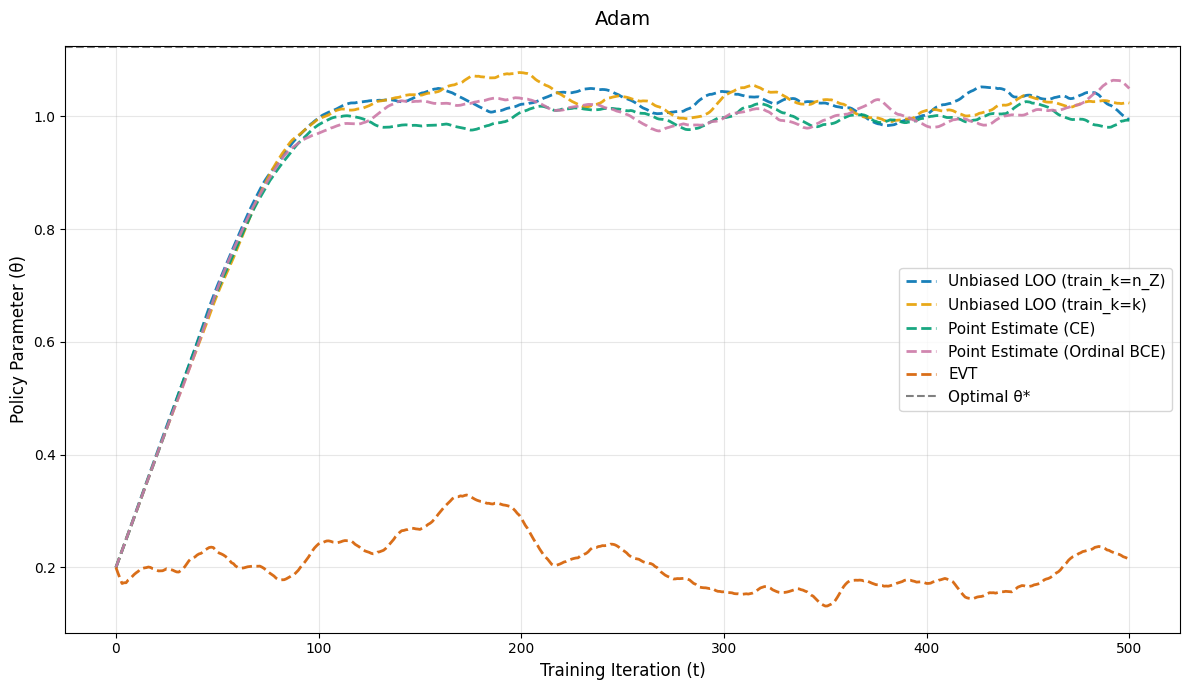

In [22]:
# =====================================================================
# 3. PLOT THE LEARNING CURVES
# =====================================================================
TRAJECTORY_SMOOTH_WINDOW = 25  # centered moving average; 1 = raw (match metrics cell)


# Okabe-Ito-style palette: colorblind-safe, spaced across hues (not the earlier `colors` from pass@k curves)
_line_colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # red-purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#000000",  # black
    "#F0E442",  # yellow
    "#A65628",  # brown
]
plt.figure(figsize=(12, 7))

for idx, method in enumerate(thetas.keys()):
    plt.plot(trajectories[method], label=method, alpha=0.9, color=_line_colors[idx], linewidth=2, linestyle='--')

plt.title("Adam", fontsize=14, pad=15)
plt.xlabel("Training Iteration (t)", fontsize=12)
plt.ylabel("Policy Parameter (θ)", fontsize=12)
# plt.ylim(0.8, 1.5)
plt.axhline(k_to_best_theta[k], color='gray', linestyle='--', label='Optimal θ*')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_242372/1700562778.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8)


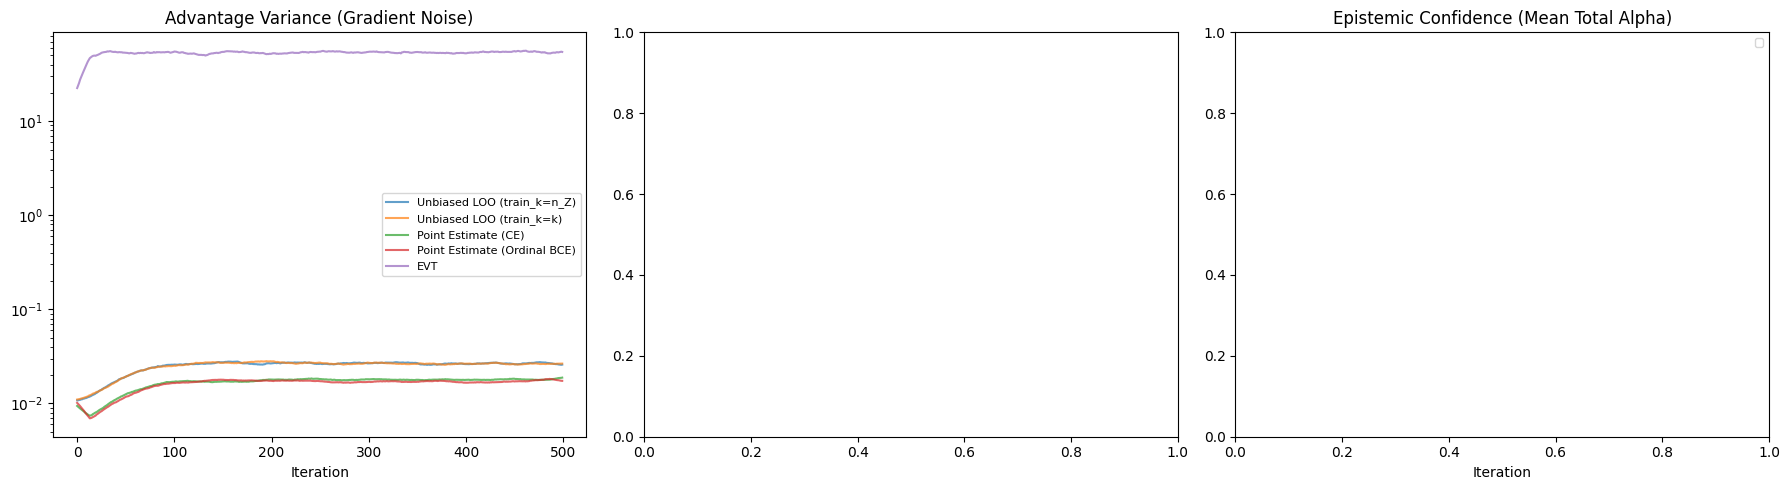


METRICS SUMMARY (Average of final 100 iterations)

--- Advantage Variance ---
  Unbiased LOO (train_k=n_Z): 0.0267
  Unbiased LOO (train_k=k): 0.0264
  Point Estimate (CE): 0.0180
  Point Estimate (Ordinal BCE): 0.0173
  EVT: 54.2019

--- Mean Baseline E[M_{k-1}] ---
  Point Estimate (CE): 0.3492
  Point Estimate (Ordinal BCE): 0.2823
  EVT: -5.7665

--- Epistemic Confidence (Total Alpha_0) ---


In [23]:
# =====================================================================
# 5. VISUALIZE AND PRINT INTERNAL METRICS
# =====================================================================
METRIC_SMOOTH_WINDOW = 25  # centered moving average; use 1 for raw trajectories

def _smooth_1d(y, window):
    y = np.asarray(y, dtype=float)
    w = int(window)
    if w <= 1 or len(y) < 3:
        return y
    if w % 2 == 0:
        w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(ypad, kernel, mode="valid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Advantage Variance
for m, vals in track_adv_var.items():
    axes[0].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, alpha=0.7)
axes[0].set_title("Advantage Variance (Gradient Noise)")
axes[0].set_yscale('log') # Log scale because CE variance explodes
axes[0].set_xlabel("Iteration")
axes[0].legend(fontsize=8)

# Plot 3: Epistemic Confidence (Alpha_0)
for m, vals in track_alpha0.items():
    axes[2].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, alpha=0.7)
axes[2].set_title("Epistemic Confidence (Mean Total Alpha)")
axes[2].set_xlabel("Iteration")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('variance.png')
plt.show()

# Print Summary for LLM Context
print("\n" + "="*60)
print("METRICS SUMMARY (Average of final 100 iterations)")
print("="*60)

print("\n--- Advantage Variance ---")
for m, vals in track_adv_var.items():
    print(f"  {m}: {np.mean(vals[-100:]):.4f}")
    
print("\n--- Mean Baseline E[M_{k-1}] ---")
for m, vals in track_baseline_mean.items():
    print(f"  {m}: {np.mean(vals[-100:]):.4f}")
    
print("\n--- Epistemic Confidence (Total Alpha_0) ---")
for m, vals in track_alpha0.items():
    print(f"  {m}: {np.mean(vals[-100:]):.4f}")
print("="*60)


In [34]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# =====================================================================
# 2.5 ACTOR NETWORK & ENVIRONMENT SIMULATOR
# =====================================================================
SIGMA = 0.2
TAU_SCALE = 0.2
X_DIM = 16

# class ActorNet(nn.Module):
#     def __init__(self, in_features: int = 16, hidden: int = 64):
#         super().__init__()
#         self.mlp = nn.Sequential(
#             nn.Linear(in_features, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, 1) # Outputs the mean (mu) for Z
#         )

#     def forward(self, x: torch.Tensor):
#         return self.mlp(x).squeeze(-1)

class ActorNet(nn.Module):
    def __init__(self, in_features: int = 16, hidden: int = 64):
        super().__init__()
        self.base = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, 1)
        self.log_sigma_head = nn.Linear(hidden, 1)
        
        # Initialize log_sigma to start near our old SIGMA=0.2 (log(0.2) ≈ -1.6)
        # This guarantees it explores widely at the start of training
        nn.init.constant_(self.log_sigma_head.bias, -1.6)
        nn.init.zeros_(self.log_sigma_head.weight)

    def forward(self, x: torch.Tensor):
        h = self.base(x)
        mu = self.mu_head(h).squeeze(-1)
        log_sigma = self.log_sigma_head(h).squeeze(-1)
        
        # Exponentiate to ensure sigma is strictly positive, 
        # clamp to prevent it from collapsing to absolute zero (NaN risk)
        sigma = torch.clamp(torch.exp(log_sigma), min=1e-3, max=2.0)
        return mu, sigma

def generate_env_batch(n_problems, actor, n_draws):
    """
    Dynamically generates states, queries the actor for actions (Z), 
    and evaluates the complex multi-modal reward (Y).
    """
    # 1. Generate X (States)
    x0 = np.random.uniform(0.5, 1.5, n_problems)
    extras = np.random.standard_normal((n_problems, X_DIM - 1))
    X = np.column_stack([x0, extras])
    X_t = torch.tensor(X, dtype=torch.float64)

    with torch.no_grad():
        # Actor now predicts both mean AND standard deviation
        mu_t, sigma_t = actor(X_t)

    epsilon = torch.randn(n_problems, n_draws, dtype=torch.float64)
    # Apply the state-specific sigma to the noise
    Z_t = mu_t.unsqueeze(-1) + sigma_t.unsqueeze(-1) * epsilon

    # 4. Compute Y (Multi-modal non-linear target)
    x0_t = X_t[:, 0]
    extras_t = X_t[:, 1:]

    base_target = (
        x0_t**2 
        + 0.2 * torch.sin(3 * extras_t[:, 0]) 
        + 0.2 * torch.cos(3 * extras_t[:, 1]) 
        + 0.1 * extras_t[:, 2] * extras_t[:, 3]
    )

    W = 0.07 - 0.04 * x0_t
    tau = TAU_SCALE * torch.sqrt(W)

    target_3d = base_target.unsqueeze(-1)
    tau_3d = tau.unsqueeze(-1)

    Y1 = 0.5 * torch.exp(-((Z_t - target_3d + 0.6)**2) / (2 * (2 * tau_3d)**2))
    Y2 = 0.8 * torch.exp(-((Z_t - target_3d)**2) / (2 * tau_3d**2))
    Y3 = 1.0 * torch.exp(-((Z_t - target_3d - 0.5)**2) / (2 * (tau_3d / 2)**2))

    Y_t = torch.clamp(Y1 + Y2 + Y3, 0.0, 1.0)

    return X_t, Z_t, Y_t


# =====================================================================
# 3. SETUP THE RL ENVIRONMENT
# =====================================================================
n_X = 512
n_Z = 4
k = 4
NUM_BINS = 1000
iterations = 500
base_lr = 0.01 

net_lr = 0.01
wd = 0
net_hidden = 128
inner_steps = 10

# Initialize Critic/Baseline Networks
ce_net = SoftmaxNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
ce_opt = torch.optim.Adam(ce_net.parameters(), lr=net_lr, weight_decay=wd)

cramer_net = SoftmaxNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
cramer_opt = torch.optim.Adam(cramer_net.parameters(), lr=net_lr, weight_decay=wd)

eb_net = DirichletNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
eb_opt = torch.optim.Adam(eb_net.parameters(), lr=net_lr, weight_decay=wd)

eb_net_defer = DirichletNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
eb_opt_defer = torch.optim.Adam(eb_net_defer.parameters(), lr=net_lr, weight_decay=wd)

evt_net = EVTNet(hidden=net_hidden, in_features=X_DIM).double()
evt_opt = torch.optim.Adam(evt_net.parameters(), lr=net_lr)

pava_net = SigmoidNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
pava_opt = torch.optim.Adam(pava_net.parameters(), lr=net_lr, weight_decay=wd)

method_names = [
    'Unbiased LOO (train_k=n_Z)',
    'Unbiased LOO (train_k=k)',
    'Point Estimate (CE)',
    'Point Estimate (Cramer)',
    'Point Estimate (Ordinal BCE)',
    'Dirichlet-Multinomial (Train-then-Infer)',
    'Dirichlet-Multinomial (Infer-then-Train)',
    # 'EVT'
]

# Initialize Independent Actors for each method
actors = {m: ActorNet(in_features=X_DIM, hidden=net_hidden).double() for m in method_names}
actor_opts = {m: torch.optim.Adam(actors[m].parameters(), lr=base_lr) for m in method_names}

# Tracking Metrics (Replacing scalar thetas with average reward)
track_adv_var = {m: [] for m in method_names}
track_baseline_mean = {m: [] for m in method_names if 'LOO' not in m}
track_alpha0 = {m: [] for m in method_names if 'Dirichlet' in m}
track_max_reward = {m: [] for m in method_names}

print("Starting max@k REINFORCE training with Neural Actors...")


# =====================================================================
# 4. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    for method in method_names:
        actor = actors[method]
        
        # 1. Generate Environment Data dynamically via the current actor
        X_t, Z_t, Y_t = generate_env_batch(n_X, actor, n_Z)
        
        # Empirical Bin Counts
        bin_indices = torch.clamp((Y_t * NUM_BINS).long(), 0, NUM_BINS - 1)
        Y_one_hot = F.one_hot(bin_indices, NUM_BINS).double()
        C_total = Y_one_hot.sum(dim=1)
        C_loo = C_total.unsqueeze(1) - Y_one_hot

        # -----------------------------------------------------------------
        # COMPUTE ADVANTAGE (adv)
        # -----------------------------------------------------------------
        if method == 'Unbiased LOO (train_k=n_Z)':
            Y_np = Y_t.cpu().numpy()
            j_drop = np.arange(n_Z)[:, None]
            kk = np.arange(n_Z - 1)[None, :]
            col = np.where(kk < j_drop, kk, kk + 1)
            loo_baseline_np = Y_np[:, col].max(axis=-1)
            
            loo_baseline = torch.tensor(loo_baseline_np, device=Y_t.device)
            adv = Y_t.max(dim=-1, keepdim=True).values - loo_baseline

        elif method == 'Unbiased LOO (train_k=k)':
            aX_t, aZ_t, aY_t = generate_env_batch(n_X, actor, k)
            aY_np = aY_t.cpu().numpy()
            j_drop = np.arange(k)[:, None]
            kk = np.arange(k - 1)[None, :]
            col = np.where(kk < j_drop, kk, kk + 1)
            loo_baseline_np = aY_np[:, col].max(axis=-1)
            
            loo_baseline = torch.tensor(loo_baseline_np, device=aY_t.device)
            adv = aY_t.max(dim=-1, keepdim=True).values - loo_baseline
            
            # Override Z_t and X_t for the actor update so they match the advantage
            Z_t = aZ_t 
            X_t = aX_t

        elif method == 'Point Estimate (CE)':
            ce_net.train()
            for _ in range(inner_steps):
                ce_opt.zero_grad(set_to_none=True)
                alphas = ce_net(X_t)
                loss = cross_entropy_loss(alphas, C_total)
                loss.backward()
                ce_opt.step()
            ce_net.eval()
            with torch.no_grad():
                predicted_pdf = ce_net(X_t)
            
            reward = conditional_max_at_k(predicted_pdf, Y_t, k, NUM_BINS)
            # baseline = max_at_k(predicted_pdf, k, NUM_BINS) 
            # adv = reward - baseline.unsqueeze(-1)
            adv = reward - reward.mean(dim=-1, keepdim=True)

        elif method == 'Point Estimate (Cramer)':
            cramer_net.train()
            for _ in range(inner_steps):
                cramer_opt.zero_grad(set_to_none=True)
                alphas = cramer_net(X_t)
                loss = cramer_distance_loss(alphas, C_total)
                loss.backward()
                cramer_opt.step()
            cramer_net.eval()
            with torch.no_grad():
                predicted_pdf = cramer_net(X_t)
            
            reward = conditional_max_at_k(predicted_pdf, Y_t, k, NUM_BINS)
            baseline = max_at_k(predicted_pdf, k-1, NUM_BINS) 
            adv = reward - baseline.unsqueeze(-1)

        elif method == 'Point Estimate (Ordinal BCE)':
            pava_net.train()
            for _ in range(inner_steps):
                pava_opt.zero_grad(set_to_none=True)
                raw_cdf = pava_net(X_t)
                loss = ordinal_bce_loss(raw_cdf, C_total)
                loss.backward()
                pava_opt.step()

            pava_net.eval()
            with torch.no_grad():
                raw_cdf = pava_net(X_t)
                iso_cdf = apply_pava_batched(raw_cdf)

                zero_pad = torch.zeros((*iso_cdf.shape[:-1], 1), device=X_t.device, dtype=X_t.dtype)
                one_pad = torch.ones((*iso_cdf.shape[:-1], 1), device=X_t.device, dtype=X_t.dtype)
                full_cdf = torch.cat([zero_pad, iso_cdf, one_pad], dim=-1)
                pmf = full_cdf[..., 1:] - full_cdf[..., :-1]

            reward = conditional_max_at_k(pmf, Y_t, k, NUM_BINS)
            baseline = max_at_k(pmf, k-1, NUM_BINS) 
            adv = reward - baseline.unsqueeze(-1)

        elif method == 'Dirichlet-Multinomial (Train-then-Infer)':
            eb_net.train()
            for _ in range(inner_steps):
                eb_opt.zero_grad(set_to_none=True)
                alphas = eb_net(X_t)
                loss = dirichlet_multinomial_nll_loss(alphas, C_total)
                loss.backward()
                eb_opt.step()
            eb_net.eval()
            with torch.no_grad():
                prior_alphas = eb_net(X_t)
                
            posterior_alphas = prior_alphas.unsqueeze(1) + C_loo
            baseline = integrated_max_at_k(posterior_alphas, k, NUM_BINS)
            reward = conditional_integrated_max_k(posterior_alphas, Y_t, k, NUM_BINS)
            adv = reward - baseline

        elif method == 'Dirichlet-Multinomial (Infer-then-Train)':
            eb_net_defer.eval()
            with torch.no_grad():
                prior_alphas = eb_net_defer(X_t)
            
            posterior_alphas = prior_alphas.unsqueeze(1) + C_loo
            baseline = integrated_max_at_k(posterior_alphas, k, NUM_BINS)
            reward = conditional_integrated_max_k(posterior_alphas, Y_t, k, NUM_BINS)
            adv = reward - baseline
            
            eb_net_defer.train()
            for _ in range(inner_steps):
                eb_opt_defer.zero_grad(set_to_none=True)
                alphas = eb_net_defer(X_t)
                loss = dirichlet_multinomial_nll_loss(alphas, C_total)
                loss.backward()
                eb_opt_defer.step()

        elif method == 'EVT':
            evt_net.train()
            Y_max = Y_t.max(dim=-1).values
            for _ in range(inner_steps):
                evt_opt.zero_grad(set_to_none=True)
                mu, beta = evt_net(X_t)
                loss = gumbel_nll_loss(mu, beta, Y_max)
                loss.backward()
                evt_opt.step()
            evt_net.eval()
            with torch.no_grad():
                mu, beta = evt_net(X_t)
            
            baseline = evt_max_at_k(mu, beta, current_k=n_Z, target_k=k)
            reward = evt_conditional_max_at_k(mu, beta, Y_t, current_k=n_Z, target_k=k-1)
            adv = reward - baseline.unsqueeze(-1)


        # POLICY GRADIENT UPDATE (ACTOR)
        # -----------------------------------------------------------------
        adv = adv.detach()

        actor.train()
        mu_train, sigma_train = actor(X_t)
        
        # The distribution now uses the actor's predicted variance
        dist = torch.distributions.Normal(mu_train.unsqueeze(-1), sigma_train.unsqueeze(-1))
        log_probs = dist.log_prob(Z_t)

        actor_loss = -(adv * log_probs).mean()
        
        actor_opts[method].zero_grad()
        actor_loss.backward()
        actor_opts[method].step()

        # -----------------------------------------------------------------
        # LOG INTERNAL METRICS
        # -----------------------------------------------------------------
        track_adv_var[method].append(adv.var().item())
        track_max_reward[method].append(Y_t.max(dim=-1).values.mean().item())

        if 'LOO' not in method:
            track_baseline_mean[method].append(baseline.mean().item())

        if 'Dirichlet' in method:
            mean_alpha0 = posterior_alphas.sum(dim=-1).mean().item()
            track_alpha0[method].append(mean_alpha0)


print("\nFinal Average Max@K Reward:")
for m, vals in track_max_reward.items():
    # Print the average reward over the last 10 iterations to smooth variance
    final_reward = np.mean(vals[-10:])
    print(f"  {m}: {final_reward:.4f}")

Starting max@k REINFORCE training with Neural Actors...

Final Average Max@K Reward:
  Unbiased LOO (train_k=n_Z): 0.3443
  Unbiased LOO (train_k=k): 0.3415
  Point Estimate (CE): 0.1357
  Point Estimate (Cramer): 0.2129
  Point Estimate (Ordinal BCE): 0.2453
  Dirichlet-Multinomial (Train-then-Infer): 0.3199
  Dirichlet-Multinomial (Infer-then-Train): 0.2110


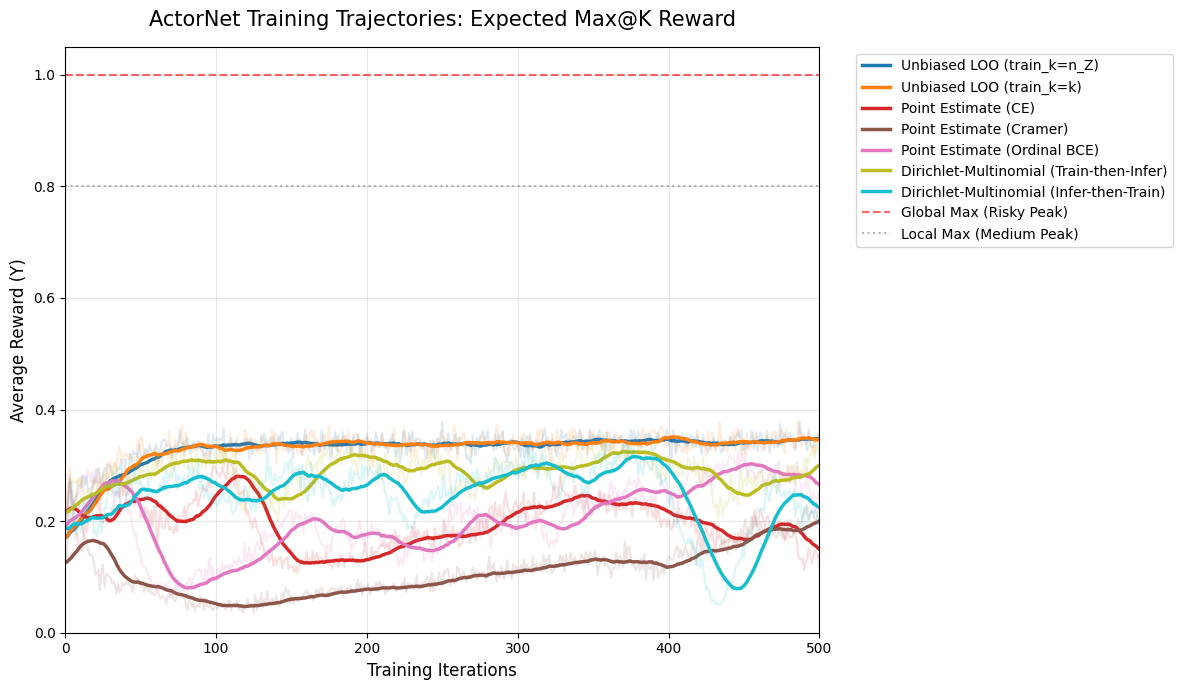

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# 5. PLOT THE REWARD TRAJECTORY
# =====================================================================
def plot_training_trajectories(reward_dict, window_size=20):
    plt.figure(figsize=(12, 7))
    
    # Generate distinct colors for each method
    methods = list(reward_dict.keys())
    cmap = plt.cm.tab10 if len(methods) <= 10 else plt.cm.tab20
    colors = cmap(np.linspace(0, 1, len(methods)))
    
    for idx, method in enumerate(methods):
        raw_rewards = np.array(reward_dict[method])
        iterations = np.arange(1, len(raw_rewards) + 1)
        
        # 1. Plot the raw, noisy trajectory (faint background)
        plt.plot(iterations, raw_rewards, color=colors[idx], alpha=0.15)
        
        # 2. Calculate and plot the smoothed moving average (solid line)
        if len(raw_rewards) >= window_size:
            # Pad the beginning so the smoothed line starts from iteration 1
            pad = np.ones(window_size - 1) * raw_rewards[0]
            padded_rewards = np.concatenate((pad, raw_rewards))
            smoothed_rewards = np.convolve(padded_rewards, np.ones(window_size)/window_size, mode='valid')
            
            plt.plot(iterations, smoothed_rewards, color=colors[idx], linewidth=2.5, label=method)
        else:
            # Fallback if training was too short for the window size
            plt.plot(iterations, raw_rewards, color=colors[idx], linewidth=2.5, label=method)

    # 3. Reference Lines for the Environment's True Peaks
    # The Safe/Broad peak (0.5), The Medium peak (0.8), The Max peak (1.0)
    plt.axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Global Max (Risky Peak)')
    plt.axhline(0.8, color='gray', linestyle=':', alpha=0.6, label='Local Max (Medium Peak)')
    
    # 4. Styling
    plt.title("ActorNet Training Trajectories: Expected Max@K Reward", fontsize=15, pad=15)
    plt.xlabel("Training Iterations", fontsize=12)
    plt.ylabel("Average Reward (Y)", fontsize=12)
    
    # Put the legend outside the plot if it gets too crowded
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=10)
    
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.05)
    plt.xlim(0, len(raw_rewards))
    plt.tight_layout()
    
    plt.show()

# Call the function using your tracking dictionary
plot_training_trajectories(track_max_reward, window_size=25)